<a href="https://colab.research.google.com/github/0xs1d/pwskills/blob/main/DA_AG_018_Anomaly_TimeSeries_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Anomaly Detection & Time Series — Assignment Solutions
**Assignment Code:** DA-AG-018


## Question 1: What is Anomaly Detection? Explain its types (point, contextual, and collective anomalies) with examples.

Anomaly Detection identifies rare or unusual patterns that differ from normal behavior.

• Point anomaly: A single unusual observation (e.g., sudden spike in credit card transaction).
• Contextual anomaly: An observation abnormal in a specific context (e.g., 30°C in winter).
• Collective anomaly: A sequence of data points abnormal together (e.g., repeated failed login attempts).

## Question 2: Compare Isolation Forest, DBSCAN, and Local Outlier Factor (LOF).

Isolation Forest isolates anomalies using random splits; works well for high-dimensional data.
DBSCAN is density-based and detects anomalies as noise points.
LOF compares local density of a point with neighbors; useful for local anomaly detection.

## Question 3: Key components of Time Series.

• Trend: Long-term movement (e.g., increasing sales).
• Seasonality: Repeating patterns (e.g., monthly airline traffic).
• Cyclic: Long-term irregular cycles.
• Noise: Random fluctuations.

## Question 4: Define Stationarity and how to test/transform.

A stationary series has constant mean and variance over time.
Test using ADF test.
Transform using differencing, log transform, or detrending.

## Question 5: Difference between AR, MA, ARIMA, SARIMA, SARIMAX.

AR: Uses past values.
MA: Uses past errors.
ARIMA: Combines AR + MA + differencing.
SARIMA: ARIMA with seasonal terms.
SARIMAX: SARIMA with exogenous variables.

## Question 6: Decompose AirPassengers Dataset

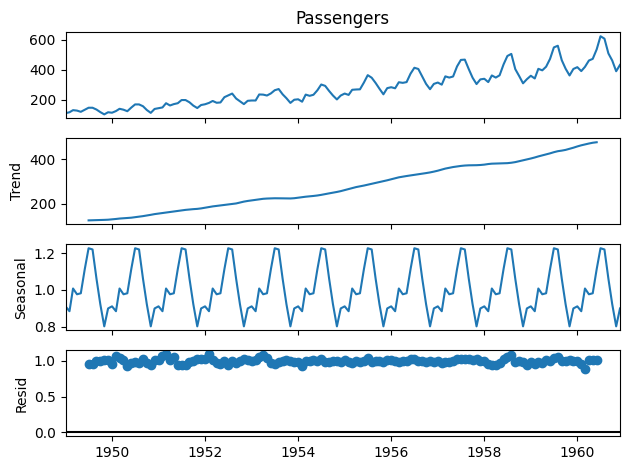

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
data = pd.read_csv(url, parse_dates=['Month'], index_col='Month')

result = seasonal_decompose(data['Passengers'], model='multiplicative')
result.plot()
plt.show()

## Question 7: Isolation Forest on synthetic Taxi Fare data

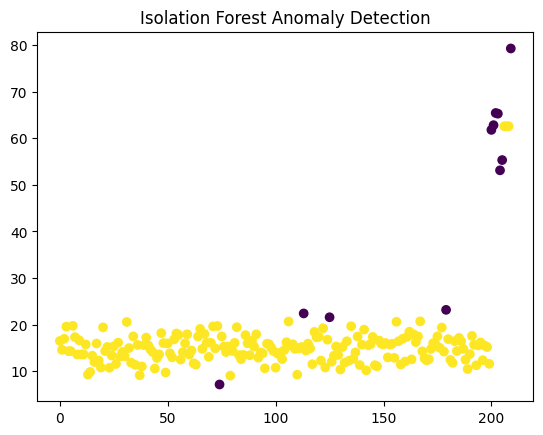

In [2]:
import numpy as np
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

np.random.seed(42)
fare = np.concatenate([np.random.normal(15, 3, 200), np.random.normal(60, 5, 10)])
X = fare.reshape(-1, 1)

model = IsolationForest(contamination=0.05, random_state=42)
pred = model.fit_predict(X)

plt.scatter(range(len(fare)), fare, c=pred)
plt.title("Isolation Forest Anomaly Detection")
plt.show()

## Question 8: SARIMA Forecasting (AirPassengers)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


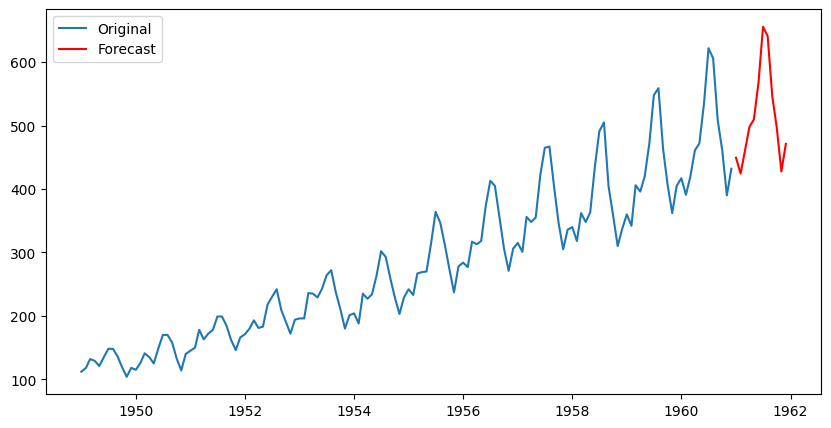

In [3]:
import statsmodels.api as sm

model = sm.tsa.statespace.SARIMAX(data['Passengers'],
                                   order=(1,1,1),
                                   seasonal_order=(1,1,1,12))
results = model.fit()

forecast = results.get_forecast(steps=12)
pred_mean = forecast.predicted_mean

plt.figure(figsize=(10,5))
plt.plot(data.index, data['Passengers'], label='Original')
plt.plot(pred_mean.index, pred_mean, label='Forecast', color='red')
plt.legend()
plt.show()

## Question 9: Local Outlier Factor (LOF)

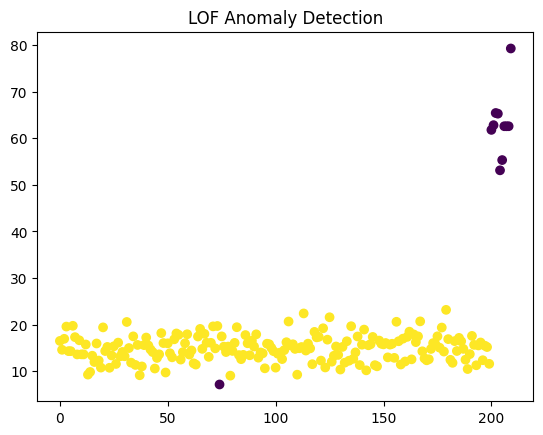

In [4]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
y_pred = lof.fit_predict(X)

plt.scatter(range(len(fare)), fare, c=y_pred)
plt.title("LOF Anomaly Detection")
plt.show()

## Question 10: Real-time Energy Forecasting & Anomaly Detection Workflow


### Anomaly Detection:
Use Isolation Forest for streaming anomaly detection due to speed and scalability.

### Forecasting Model:
Use SARIMAX since weather variables act as exogenous features.

### Validation & Monitoring:
• Rolling window cross-validation  
• Monitor RMSE, MAE  
• Real-time dashboards  

### Business Impact:
• Detect abnormal spikes/drops  
• Prevent grid failures  
• Improve demand planning  
